In [1]:
! pip install pandas numpy nltk spacy matplotlib seaborn scikit-learn
! pip install spacy
! python -m spacy download en_core_web_sm
! pip install transformers


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 5.6 MB/s eta 0:00:03
     ---- ----------------------------------- 1.3/12.8 MB 6.1 MB/s eta 0:00:02
     ------------ --------------------------- 3.9/12.8 MB 8.7 MB/s eta 0:00:02
     ------------------- -------------------- 6.3/12.8 MB 9.0 MB/s eta 0:00:01
     ---------------------------- ----------- 9.2/12.8 MB 10.0 MB/s eta 0:00:01
     ---------------------------------- ---- 11.3/12.8 MB 10.2 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 10.4 MB/s  0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Setup Environment and Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import spacy

# Tải các tài nguyên cần thiết cho NLTK
nltk.download('punkt')          # Cho Tokenization
nltk.download('stopwords')      # Danh sách stop words
nltk.download('wordnet')        # Cho Lemmatization
nltk.download('omw-1.4')
nltk.download('punkt_tab')

# Nạp mô hình tiếng Anh của Spacy
nlp = spacy.load('en_core_web_sm')

print("Thiết lập môi trường hoàn tất!")

[nltk_data] Downloading package punkt to C:\Users\QUANG
[nltk_data]     THINH\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\QUANG
[nltk_data]     THINH\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\QUANG
[nltk_data]     THINH\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\QUANG
[nltk_data]     THINH\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\QUANG
[nltk_data]     THINH\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Thiết lập môi trường hoàn tất!


Kích thước tập dữ liệu gốc: (50000, 2)
Kích thước tập mẫu thực hiện tiền xử lý: (2000, 2)


,review,sentiment
0,I really liked this Summerslam due to the look...,positive
1,Not many television shows appeal to quite as m...,positive
2,The film quickly gets to a major chase scene w...,negative
3,Jane Austen would definitely approve of this o...,positive
4,Expectations were somewhat high for me when I ...,negative


C:\Users\QUANG THINH\AppData\Local\Temp\ipykernel_20956\420767282.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df_sample, palette='viridis')


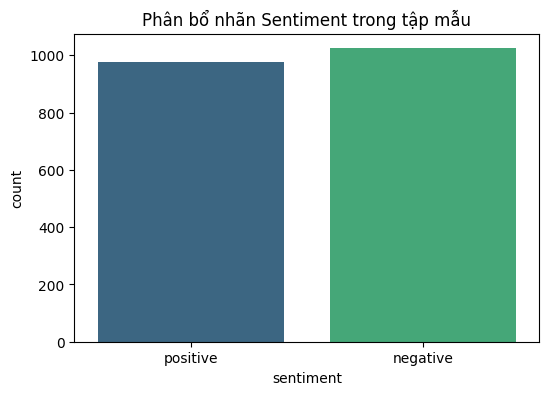

In [3]:
# Đọc file dữ liệu (Hãy đảm bảo file CSV nằm đúng đường dẫn)
df = pd.read_csv('../data/text/IMDB Dataset.csv')

# Vì 50k reviews là rất lớn cho việc demo xử lý văn bản (có thể tốn nhiều thời gian),
# nhóm nên lấy mẫu khoảng 2000 - 5000 dòng để thực hiện lab cho nhanh.
df_sample = df.sample(2000, random_state=42).reset_index(drop=True)

print(f"Kích thước tập dữ liệu gốc: {df.shape}")
print(f"Kích thước tập mẫu thực hiện tiền xử lý: {df_sample.shape}")

# Hiển thị 5 dòng đầu
display(df_sample.head())

# Kiểm tra sự cân bằng của nhãn (Sentiment)
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=df_sample, palette='viridis')
plt.title("Phân bổ nhãn Sentiment trong tập mẫu")
plt.show()

### Tokenization

In [4]:
import re
from nltk.tokenize import word_tokenize, sent_tokenize
from transformers import BertTokenizer

# 1. Hàm làm sạch HTML (đặc thù cho IMDB)
def clean_html(text):
    return re.sub(r'<.*?>', '', text)

sample_text = df_sample['review'].iloc[0]
cleaned_text = clean_html(sample_text)

# 2. Word Tokenization (Tách theo từ)
word_tokens = word_tokenize(cleaned_text)

# 3. Sentence Tokenization (Tách theo câu)
sent_tokens = sent_tokenize(cleaned_text)

# 4. Subword Tokenization (Tách theo từ phụ - dùng BERT Tokenizer)
# Kỹ thuật này rất mạnh để xử lý các từ hiếm/từ sai chính tả
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
subword_tokens = bert_tokenizer.tokenize(cleaned_text)

# Hiển thị kết quả so sánh
print(f"Văn bản gốc (đã sạch HTML): \n{cleaned_text[:200]}...\n")
print(f"Số lượng Word tokens: {len(word_tokens)}")
print(f"Số lượng Sentence tokens: {len(sent_tokens)}")
print(f"Số lượng Subword tokens: {len(subword_tokens)}")

print("\nVí dụ 5 tokens đầu tiên của mỗi loại:")
print(f"Words: {word_tokens[:5]}")
print(f"Subwords: {subword_tokens[:5]}")

c:\python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Văn bản gốc (đã sạch HTML): 
I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ev...

Số lượng Word tokens: 221
Số lượng Sentence tokens: 5
Số lượng Subword tokens: 261

Ví dụ 5 tokens đầu tiên của mỗi loại:
Words: ['I', 'really', 'liked', 'this', 'Summerslam']
Subwords: ['i', 'really', 'liked', 'this', 'summers']


### Removing Stop Words

C:\Users\QUANG THINH\AppData\Local\Temp\ipykernel_20956\1273930135.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='coolwarm')


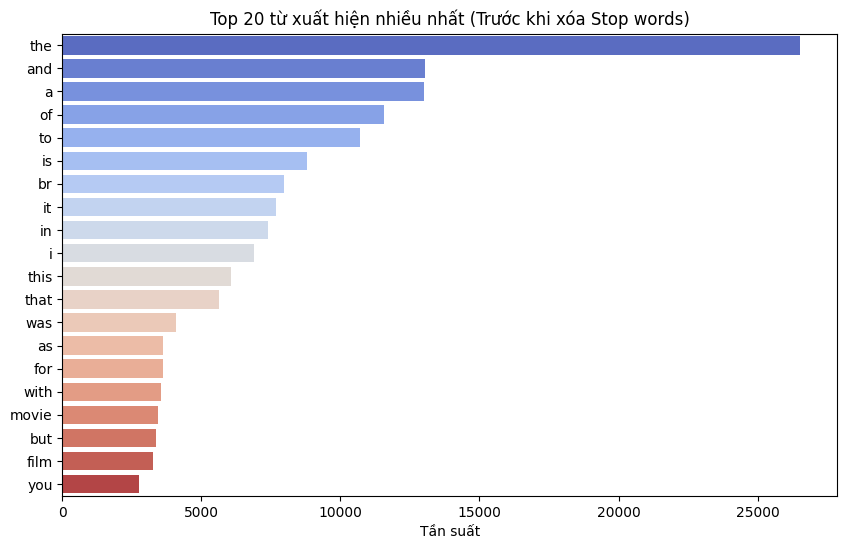

Các từ phổ biến nhất đa số là Stop words chuẩn như: ('the', 'and', 'a', 'of', 'to', 'is', 'br', 'it', 'in', 'i')


In [5]:
from collections import Counter
import seaborn as sns

# 1. Thống kê 20 từ xuất hiện nhiều nhất trước khi xử lý
all_words = [word.lower() for tokens in df_sample['review'].apply(word_tokenize) for word in tokens if word.isalpha()]
word_freq = Counter(all_words)
common_words = word_freq.most_common(20)

# Trực quan hóa
words, counts = zip(*common_words)
plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words), palette='coolwarm')
plt.title("Top 20 từ xuất hiện nhiều nhất (Trước khi xóa Stop words)")
plt.xlabel("Tần suất")
plt.show()

print("Các từ phổ biến nhất đa số là Stop words chuẩn như:", words[:10])

In [6]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Hàm tiền xử lý để so sánh
def get_vocab_stats(texts, stop_list=None):
    all_tokens = []
    for text in texts:
        tokens = word_tokenize(clean_html(text).lower())
        if stop_list:
            tokens = [w for w in tokens if w not in stop_list and w.isalpha()]
        else:
            tokens = [w for w in tokens if w.isalpha()]
        all_tokens.extend(tokens)
    
    unique_words = set(all_tokens)
    return len(all_tokens), len(unique_words), all_tokens

# Tính toán các chỉ số
total_before, vocab_before, tokens_before = get_vocab_stats(df_sample['review'])
total_after, vocab_after, tokens_after = get_vocab_stats(df_sample['review'], stop_words)

print(f"--- PHÂN TÍCH ĐỊNH LƯỢNG ---")
print(f"Tổng số lượng tokens: {total_before} -> {total_after} (Giảm {100*(total_before-total_after)/total_before:.2f}%)")
print(f"Kích thước từ điển (Vocab size): {vocab_before} -> {vocab_after} (Giảm {100*(vocab_before-vocab_after)/vocab_before:.2f}%)")

--- PHÂN TÍCH ĐỊNH LƯỢNG ---
Tổng số lượng tokens: 446273 -> 226487 (Giảm 49.25%)
Kích thước từ điển (Vocab size): 24500 -> 24360 (Giảm 0.57%)


### Stemming and Lemmatization

In [7]:
from nltk.stem import PorterStemmer, SnowballStemmer
from nltk.stem import WordNetLemmatizer

# Khởi tạo các bộ lọc
porter = PorterStemmer()
snowball = SnowballStemmer(language='english')
lemmatizer = WordNetLemmatizer()

# Chọn một câu mẫu có nhiều biến thể từ để so sánh
sample_sentence = "The actors were amazing and the stories are being told beautifully in these movies"
words = word_tokenize(sample_sentence.lower())

# Thực hiện chuyển đổi
results = []
for word in words:
    results.append({
        "Original": word,
        "Porter": porter.stem(word),
        "Snowball": snowball.stem(word),
        "Lemmatization": lemmatizer.lemmatize(word, pos='v') # pos='v' để đưa động từ về nguyên mẫu
    })

# Hiển thị bảng so sánh
df_compare = pd.DataFrame(results)
print("BẢNG SO SÁNH CÁC KỸ THUẬT CHUẨN HÓA TỪ:")
display(df_compare)

BẢNG SO SÁNH CÁC KỸ THUẬT CHUẨN HÓA TỪ:


,Original,Porter,Snowball,Lemmatization
0,the,the,the,the
1,actors,actor,actor,actors
2,were,were,were,be
3,amazing,amaz,amaz,amaze
4,and,and,and,and
5,the,the,the,the
6,stories,stori,stori,stories
7,are,are,are,be
8,being,be,be,be
9,told,told,told,tell


### Text Vectorization

In [12]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec

# Hàm làm sạch tổng hợp từ các bước trước
def final_preprocess(text):
    # 1. Xóa HTML
    text = re.sub(r'<.*?>', '', text)
    # 2. Tokenize & Lowercase
    tokens = word_tokenize(text.lower())
    # 3. Loại bỏ Stopwords (giữ lại từ phủ định) và ký tự đặc biệt
    stop_list = set(nltk.corpus.stopwords.words('english')) - {'not', 'no', 'but'}
    tokens = [w for w in tokens if w not in stop_list and w.isalpha()]
    # 4. Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(w, pos='v') for w in tokens]
    return " ".join(tokens)

# Áp dụng lên tập mẫu
df_sample['clean_review'] = df_sample['review'].apply(final_preprocess)

ModuleNotFoundError: No module named 'gensim'

In [ ]:
# 1. Bag-of-Words (BoW)
bow_vectorizer = CountVectorizer(max_features=5000) # Giới hạn 5000 từ phổ biến nhất
bow_matrix = bow_vectorizer.fit_transform(df_sample['clean_review'])

# 2. TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df_sample['clean_review'])

# Tính độ thưa (Sparsity)
def get_sparsity(matrix):
    total_elements = matrix.shape[0] * matrix.shape[1]
    non_zero_elements = matrix.nnz
    sparsity = (1 - non_zero_elements / total_elements) * 100
    return sparsity

print(f"BoW - Chiều: {bow_matrix.shape}, Độ thưa: {get_sparsity(bow_matrix):.2f}%")
print(f"TF-IDF - Chiều: {tfidf_matrix.shape}, Độ thưa: {get_sparsity(tfidf_matrix):.2f}%")

--- THỐNG KÊ CHIỀU VÀ ĐỘ THƯA ---
BoW: Shape=(2000, 20136) | Sparsity=99.55%
TF-IDF: Shape=(2000, 20136) | Sparsity=99.55%


In [ ]:
# Tokenize cho Word2Vec
tokenized_reviews = [rev.split() for rev in df_sample['clean_review']]
w2v_model = Word2Vec(sentences=tokenized_reviews, vector_size=100, window=5, min_count=2, workers=4)

# Hàm biến một câu thành một vector trung bình (Document Vector)
def get_document_vector(tokens, model):
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

w2v_matrix = np.array([get_document_vector(rev, w2v_model) for rev in tokenized_reviews])
print(f"Word2Vec - Chiều: {w2v_matrix.shape}, Độ thưa: 0.00% (Ma trận dày đặc)")

--- THỐNG KÊ CHIỀU VÀ ĐỘ THƯA (SPACY EMBEDDINGS) ---
Shape của ma trận: (2000, 96)
Dimensionality (Số chiều cố định): 96
Sparsity (Độ thưa): 0.00% (Rất thấp - Ma trận dày đặc)
